In [ ]:
%load_ext autoreload
%autoreload 2

In [14]:
import csv
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

VCO_DIR = Path.cwd().resolve().parents[2] / "results" / "vco"  # notebook lives in sw/tools/notebooks/
VCO_FIELDS = ("vco_tune_coarse", "vco_current_min", "vco_current_max")

CSV_PATH = None  # e.g. VCO_DIR / "vctrl_sweep_c8_min12_max0_20260928_132515.csv"

if CSV_PATH is None:
    CSV_PATH = sorted(VCO_DIR.glob("vctrl_sweep_*.csv"), key=lambda p: p.stat().st_mtime)[-1]
CSV_PATH = Path(CSV_PATH)
print(CSV_PATH)

/users/micas/wvandest/projects/lagd-meas/results/vco/vctrl_sweep_c8_min12_max0_20260928_135113.csv


In [15]:
with open(CSV_PATH, newline="") as f:
    rows = list(csv.DictReader(f))
data = {k: np.array([float(r[k]) if r[k] not in ("", "None") else math.nan for r in rows]) for k in rows[0]}

settings = {k: int(data[k][0]) for k in VCO_FIELDS}
v = data["vctrl_meas"]
f_mhz = data["f_vco"] / 1e6
kvco = np.gradient(f_mhz, v)  # MHz/V, NaN next to unmeasured points
f_rel_std_ppm = data["f_std"] / data["f_meas"] * 1e6  # spread of the 10 scope readings per point

print(settings)
print(f"{len(rows)} points, {int(np.sum(np.isnan(f_mhz)))} without a frequency")
print(f"f_vco {np.nanmin(f_mhz):.1f} .. {np.nanmax(f_mhz):.1f} MHz, "
      f"Kvco {np.nanmin(kvco):.0f} .. {np.nanmax(kvco):.0f} MHz/V, "
      f"f std/f {np.nanmin(f_rel_std_ppm):.0f} .. {np.nanmax(f_rel_std_ppm):.0f} ppm, "
      f"max |I(Vctrl)| {np.nanmax(np.abs(data['i_ctrl'])) * 1e9:.2f} nA")

{'vco_tune_coarse': 8, 'vco_current_min': 12, 'vco_current_max': 0}
31 points, 0 without a frequency
f_vco 419.6 .. 1238.6 MHz, Kvco -7803 .. 5 MHz/V, f std/f 0 .. 9827 ppm, max |I(Vctrl)| 1.73 nA


In [16]:
SURFACE, INK, GRID, BLUE = "#fcfcfb", "#52514e", "#e4e3df", "#2a78d6"
SUBTITLE = "coarse {vco_tune_coarse}, min {vco_current_min}, max {vco_current_max}".format(**settings)


def plot_vs_vctrl(y, ylabel, title, name, zero_line=False):
    """One figure of `y` against the measured Vctrl, shown and saved as <csv stem>_<name>.png."""
    fig, ax = plt.subplots(figsize=(8, 4.5), facecolor=SURFACE)
    ax.plot(v, y, color=BLUE, linewidth=2, marker="o", markersize=4)
    if zero_line:
        ax.axhline(0, color=INK, linewidth=0.8)
    ax.set_facecolor(SURFACE)
    ax.set_title(f"{title}\n{SUBTITLE}", fontsize=12, loc="left")
    ax.set_xlabel("Vctrl (measured) [V]", color=INK)
    ax.set_ylabel(ylabel, color=INK)
    ax.grid(True, color=GRID, linewidth=0.8)
    ax.tick_params(colors=INK, labelsize=9)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    fig.tight_layout()
    png_path = CSV_PATH.with_name(f"{CSV_PATH.stem}_{name}.png")
    fig.savefig(png_path, dpi=150, facecolor=SURFACE)
    print(f"saved {png_path}")
    plt.show()

saved /users/micas/wvandest/projects/lagd-meas/results/vco/vctrl_sweep_c8_min12_max0_20260928_135113_fvco.png


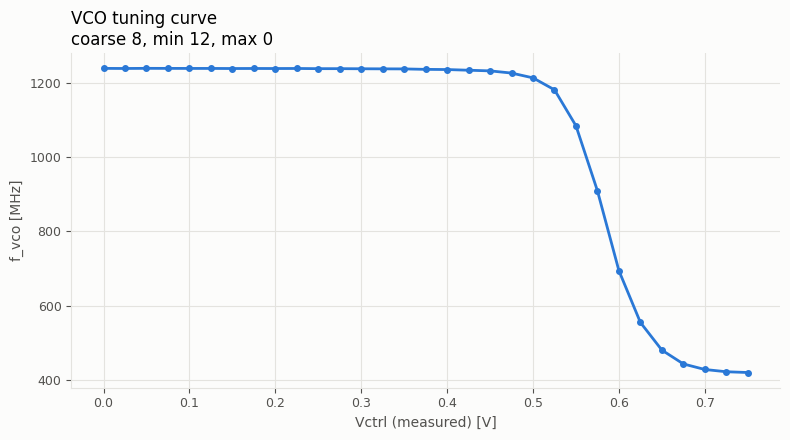

In [17]:
plot_vs_vctrl(f_mhz, "f_vco [MHz]", "VCO tuning curve", "fvco")

saved /users/micas/wvandest/projects/lagd-meas/results/vco/vctrl_sweep_c8_min12_max0_20260928_135113_kvco.png


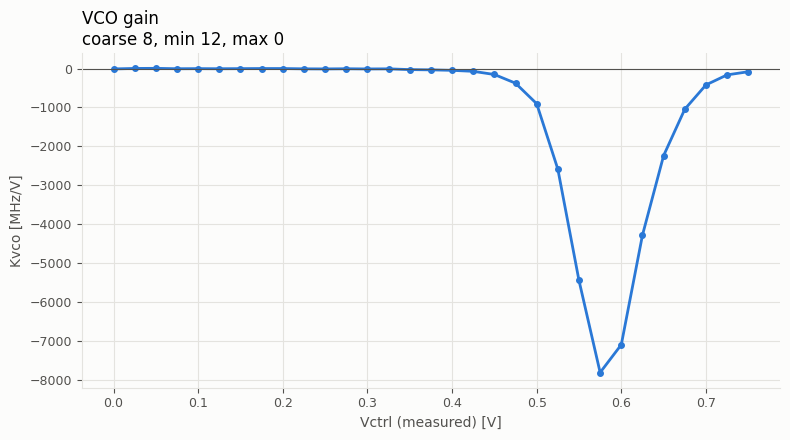

In [18]:
plot_vs_vctrl(kvco, "Kvco [MHz/V]", "VCO gain", "kvco", zero_line=True)

saved /users/micas/wvandest/projects/lagd-meas/results/vco/vctrl_sweep_c8_min12_max0_20260928_135113_fstd.png


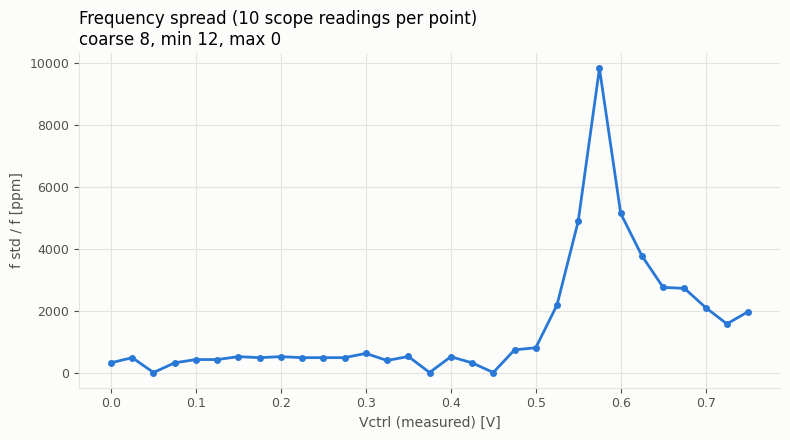

In [19]:
plot_vs_vctrl(f_rel_std_ppm, "f std / f [ppm]", "Frequency spread (10 scope readings per point)", "fstd")

saved /users/micas/wvandest/projects/lagd-meas/results/vco/vctrl_sweep_c8_min12_max0_20260928_135113_ictrl.png


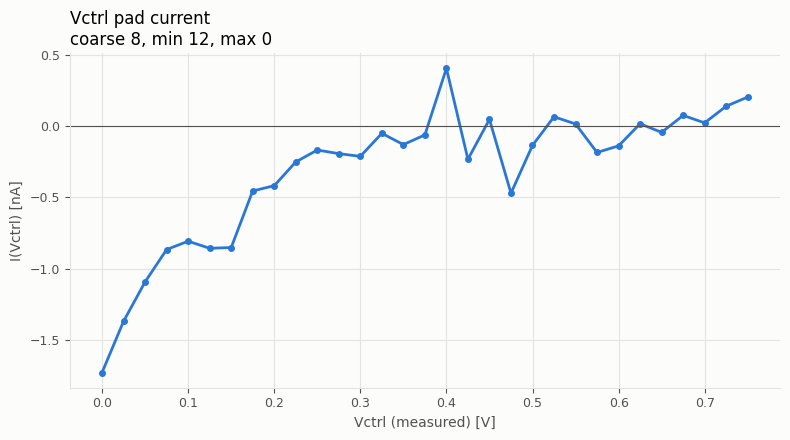

In [20]:
plot_vs_vctrl(data["i_ctrl"] * 1e9, "I(Vctrl) [nA]", "Vctrl pad current", "ictrl", zero_line=True)